In [1]:
# n = 1 (Px = 1) = 0.5
# n adet bağımsız bernoulli dağılımı.
# PMF

# 10 kez yazı tura attım 7 kez yazı gelme olasılığı
# 20 öğrenciden 15'inin sınavı geçme olasılıgı
# 5 tane e postadan2 sinin spam olma olsaılıgı

In [2]:
# Bir Fabrikada ürün üretimi var %10 ihtimalle üretilen ürün hatalı
# 10 tane üründen 2'sinin hatalı olma olasılığı nedir?

In [3]:
import numpy as np

def simulate_bernoulli_triable(p: float, n : int) -> int:
    result = np.random.binomial(n = n, p = p, size = 100)
    print(result)
    return np.sum(result)

print(simulate_bernoulli_triable(0.7, n = 1))

[1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 1 1
 0 0 0 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 0 1 1 1
 1 0 0 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 1 1 0]
68


---
# 📚 BİNOM DAĞILIMI (BINOMIAL DISTRIBUTION) - DETAYLI TEORİ VE UYGULAMA REHBERİ
### Olasılık Dağılımları Serisi - 02

---

## 📌 1. Giriş ve Sezgisel Anlatım

**Binom Dağılımı**, birbirinden bağımsız ve her birinde başarı olasılığı $p$ olan **$n$ adet özdeş Bernoulli denemesinde** elde edilen toplam başarı sayısını modelleyen **ayrık (discrete) olasılık dağılımıdır**.

Tek bir deneme söz konusu olduğunda ($n=1$) dağılım doğrudan **Bernoulli Dağılımı**'na indirgenir. Dolayısıyla Binom Dağılımı, Bernoulli'nin çoklu denemeler için genelleştirilmiş halidir.

### 🔍 Bir Deneyin Binom Dağılımı Olması İçin 4 Temel Koşul (BINS Kuralı):
1. **B (Binary - İkili Sonuç):** Her denemenin yalnızca 2 olası sonucu olmalıdır (Başarı/Başarısızlık, 1/0, Evet/Hayır).
2. **I (Independent - Bağımsızlık):** Her denemenin sonucu diğer denemelerden tamamen bağımsız olmalıdır.
3. **N (Number - Sabit Deneme Sayısı):** Deneme sayısı ($n$) deney başlamadan önce kesin olarak belirlenmiş olmalıdır.
4. **S (Same Probability - Sabit Olasılık):** Başarı olasılığı ($p$) her denemede sabit kalmalıdır.

---
## 📐 2. Matematiksel Tanım ve Olasılık Kütle Fonksiyonu (PMF)

Bir rastgele değişken $X$, $n$ deneme sayısı ve $p$ başarı olasılığı ile Binom dağılımına sahipse şu şekilde gösterilir:

$$X \sim \text{Binomial}(n, p)$$

Burada:
- $n \in \mathbb{N}^+$: Toplam bağımsız deneme sayısı
- $p \in [0, 1]$: Her bir denemedeki başarı olasılığı
- $q = 1 - p$: Başarısızlık olasılığı
- $k \in \{0, 1, 2, \dots, n\}$: Gerçekleşen başarı sayısı

### 🔹 Olasılık Kütle Fonksiyonu (Probability Mass Function - PMF)
$n$ denemede tam olarak $k$ kez başarı elde etme olasılığı:

$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}$$

Burada $\binom{n}{k}$ kombinasyon (binom katsayısı) formülüdür:

$$\binom{n}{k} = \frac{n!}{k! (n - k)!}$$

### 🔹 Kümülatif Dağılım Fonksiyonu (Cumulative Distribution Function - CDF)
$n$ denemede en fazla $k$ kez başarı elde etme olasılığı:

$$F(k) = P(X \le k) = \sum_{i=0}^k \binom{n}{i} p^i (1 - p)^{n - i}$$

---

## 📊 3. İstatistiksel Özellikler ve Momentler

| İstatistiksel Metrik | Formül | Açıklama |
| :--- | :--- | :--- |
| **Beklenen Değer (Mean / $E[X]$)** | $\mu = n \cdot p$ | Ortalama beklenen başarı sayısıdır. |
| **Varyans (Variance / $\text{Var}(X)$)** | $\sigma^2 = n \cdot p \cdot (1 - p)$ | Başarı sayısının dağılımındaki değişkenliktir. |
| **Standart Sapma (Standard Deviation)** | $\sigma = \sqrt{n \cdot p \cdot (1 - p)}$ | Varyansın kareköküdür. |
| **Çarpıklık (Skewness / $\gamma_1$)** | $\gamma_1 = \frac{1 - 2p}{\sqrt{n p (1-p)}}$ | $p = 0.5$ ise dağılım tamamen simetriktir ($\gamma_1 = 0$). |
| **Basıklık (Kurtosis Excess)** | $\text{Kurt} = \frac{1 - 6p(1-p)}{n p (1-p)}$ | $n \to \infty$ oldukça 0'a yakınsar (Normal dağılım basıklığı). |
| **Mod (Mode)** | $\lfloor (n+1)p \rfloor$ | En yüksek olasılığa sahip başarı sayısıdır. |

---
## 💻 4. Python ile Kütüphaneleri Yükleme ve Ortam Ayarları

In [4]:
# Gerekli kütüphanelerin import edilmesi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from scipy.stats import binom
from IPython.display import display

# Grafik ayarları
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Tekrarlanabilirlik tohumu
np.random.seed(42)

print("✅ Binom Dağılımı için kütüphaneler başarıyla hazırlandı!")

✅ Binom Dağılımı için kütüphaneler başarıyla hazırlandı!


---
## 🎯 5. Yukarıda Belirtilen Soruların Adım Adım Çözümleri

Notebook'un başında listelenen gerçek hayat problemlerini hem teorik formülle hem de Python ile hesaplayalım:

In [5]:
# ---------------------------------------------------------
# Soru 1: 10 kez yazı-tura atışında 7 kez yazı gelme olasılığı
# n = 10, p = 0.5, k = 7
# ---------------------------------------------------------
n1, p1, k1 = 10, 0.5, 7
prob_1 = binom.pmf(k=k1, n=n1, p=p1)

# ---------------------------------------------------------
# Soru 2: 20 öğrenciden 15'inin sınavı geçme olasılığı (Geçme oranı %70 varsayımıyla)
# n = 20, p = 0.7, k = 15
# ---------------------------------------------------------
n2, p2, k2 = 20, 0.7, 15
prob_2 = binom.pmf(k=k2, n=n2, p=p2)

# ---------------------------------------------------------
# Soru 3: 5 e-postadan 2'sinin spam olma olasılığı (Spam oranı %20 varsayımıyla)
# n = 5, p = 0.2, k = 2
# ---------------------------------------------------------
n3, p3, k3 = 5, 0.2, 2
prob_3 = binom.pmf(k=k3, n=n3, p=p3)

# ---------------------------------------------------------
# Soru 4: Fabrika Üretimi: %10 hata payı ile 10 üründen tam 2'sinin hatalı çıkması
# n = 10, p = 0.1, k = 2
# ---------------------------------------------------------
n4, p4, k4 = 10, 0.1, 2
prob_4 = binom.pmf(k=k4, n=n4, p=p4)

results_df = pd.DataFrame({
    "Problem Tanımı": [
        "10 Yazı-Tura atışında 7 Yazı",
        "20 Öğrenciden 15'inin Geçmesi (p=0.7)",
        "5 E-postadan 2'sinin Spam Olması (p=0.2)",
        "10 Üründen 2'sinin Hatalı Çıkması (p=0.1)"
    ],
    "n (Deneme)": [n1, n2, n3, n4],
    "p (Olasılık)": [p1, p2, p3, p4],
    "k (Hedef Başarı)": [k1, k2, k3, k4],
    "Hesaplanan Olasılık P(X = k)": [
        f"{prob_1:.4f} (%{prob_1*100:.2f})",
        f"{prob_2:.4f} (%{prob_2*100:.2f})",
        f"{prob_3:.4f} (%{prob_3*100:.2f})",
        f"{prob_4:.4f} (%{prob_4*100:.2f})"
    ]
})

try:
    display(results_df)
except NameError:
    print(results_df.to_string(index=False))

,Problem Tanımı,n (Deneme),p (Olasılık),k (Hedef Başarı),Hesaplanan Olasılık P(X = k)
0,10 Yazı-Tura atışında 7 Yazı,10,0.5,7,0.1172 (%11.72)
1,20 Öğrenciden 15'inin Geçmesi (p=0.7),20,0.7,15,0.1789 (%17.89)
2,5 E-postadan 2'sinin Spam Olması (p=0.2),5,0.2,2,0.2048 (%20.48)
3,10 Üründen 2'sinin Hatalı Çıkması (p=0.1),10,0.1,2,0.1937 (%19.37)


---
## 🔬 6. SciPy ile Binom Fonksiyonları (PMF, CDF, PPF, Moments)

`scipy.stats.binom` modülü Binom dağılımına ait tüm fonksiyonları içerir:
- `binom.pmf(k, n, p)`: Noktasal başarı olasılığı $P(X = k)$
- `binom.cdf(k, n, p)`: Kümülatif olasılık $P(X \le k)$
- `binom.sf(k, n, p)`: Hayatta kalma / aşma olasılığı $P(X > k) = 1 - \text{CDF}(k)$
- `binom.ppf(q, n, p)`: Ters CDF (Yüzdelik dilim / Quantile)
- `binom.rvs(n, p, size=N)`: Rastgele veri üretimi

In [6]:
# Parametreler
n = 15      # 15 deneme
p = 0.4     # Başarı olasılığı %40

# 1. Noktasal olasılık: Tam 6 başarı
pmf_6 = binom.pmf(k=6, n=n, p=p)

# 2. Kümülatif olasılık: En fazla 6 başarı P(X <= 6)
cdf_6 = binom.cdf(k=6, n=n, p=p)

# 3. En az 7 başarı P(X >= 7) = 1 - P(X <= 6)
sf_6 = binom.sf(k=6, n=n, p=p)

# 4. İstatistiksel momentler
mean, var, skew, kurt = binom.stats(n=n, p=p, moments='mvsk')

print(f"🔹 Binom(n={n}, p={p}) İstatistiksel Analiz:")
print("-" * 50)
print(f"🎯 Tam 6 Başarı Olasılığı P(X = 6)     : {pmf_6:.4f}")
print(f"📉 En Fazla 6 Başarı Olasılığı P(X <= 6): {cdf_6:.4f}")
print(f"📈 En Az 7 Başarı Olasılığı P(X >= 7)  : {sf_6:.4f}")
print(f"📊 Beklenen Değer (Ortalama E[X])      : {mean:.2f} (n*p = {n*p})")
print(f"📐 Varyans Var(X)                      : {var:.2f} (n*p*q = {n*p*(1-p):.2f})")
print(f"📏 Standart Sapma                      : {np.sqrt(var):.4f}")
print(f"📐 Çarpıklık (Skewness)                : {skew:.4f}")
print(f"📊 Basıklık (Kurtosis)                 : {kurt:.4f}")

🔹 Binom(n=15, p=0.4) İstatistiksel Analiz:
--------------------------------------------------
🎯 Tam 6 Başarı Olasılığı P(X = 6)     : 0.2066
📉 En Fazla 6 Başarı Olasılığı P(X <= 6): 0.6098
📈 En Az 7 Başarı Olasılığı P(X >= 7)  : 0.3902
📊 Beklenen Değer (Ortalama E[X])      : 6.00 (n*p = 6.0)
📐 Varyans Var(X)                      : 3.60 (n*p*q = 3.60)
📏 Standart Sapma                      : 1.8974
📐 Çarpıklık (Skewness)                : 0.1054
📊 Basıklık (Kurtosis)                 : -0.1222


---
## 📈 7. Kapsamlı Görselleştirmeler

### 🎨 Grafik 1: Farklı $p$ Başarı Olasılıklarının Binom Dağılımına Etkisi ($n = 20$)

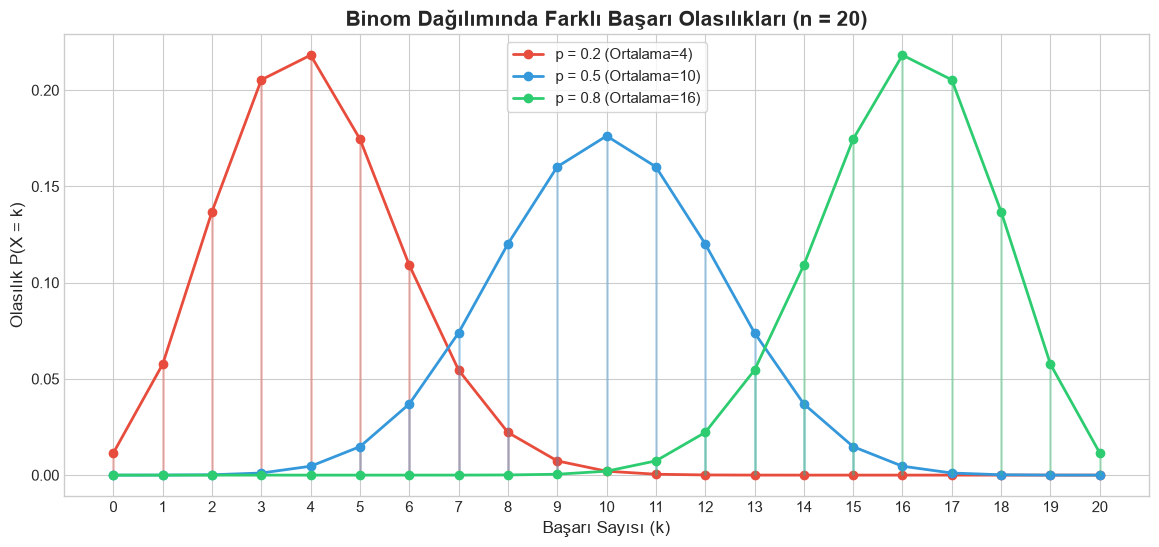

In [7]:
n = 20
k_values = np.arange(0, n + 1)
p_list = [0.2, 0.5, 0.8]
colors = ['#e74c3c', '#3498db', '#2ecc71']

plt.figure(figsize=(14, 6))

for p_val, color in zip(p_list, colors):
    pmf_vals = binom.pmf(k_values, n=n, p=p_val)
    plt.plot(k_values, pmf_vals, marker='o', linewidth=2, label=f'p = {p_val} (Ortalama={n*p_val:.0f})', color=color)
    plt.vlines(k_values, 0, pmf_vals, colors=color, alpha=0.3, linewidth=2)

plt.title(f'Binom Dağılımında Farklı Başarı Olasılıkları (n = {n})', fontsize=15, fontweight='bold')
plt.xlabel('Başarı Sayısı (k)', fontsize=12)
plt.ylabel('Olasılık P(X = k)', fontsize=12)
plt.xticks(k_values)
plt.legend(frameon=True, fontsize=11)
plt.show()

### 🎨 Grafik 2: Deneme Sayısı ($n$) Arttıkça Binom Dağılımının Normal Dağılıma Yakınsaması (Merkezi Limit Teoremi)

<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/63/dblmft916gb17xgfh55xpb980000gn/T/ipykernel_97264/2841478245.py:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[idx].set_title(f'n = {n_val}, p = {p}\n$\mu={mu:.1f}, \sigma={sigma:.2f}$', fontsize=13, fontweight='bold')
/var/folders/63/dblmft916gb17xgfh55xpb9

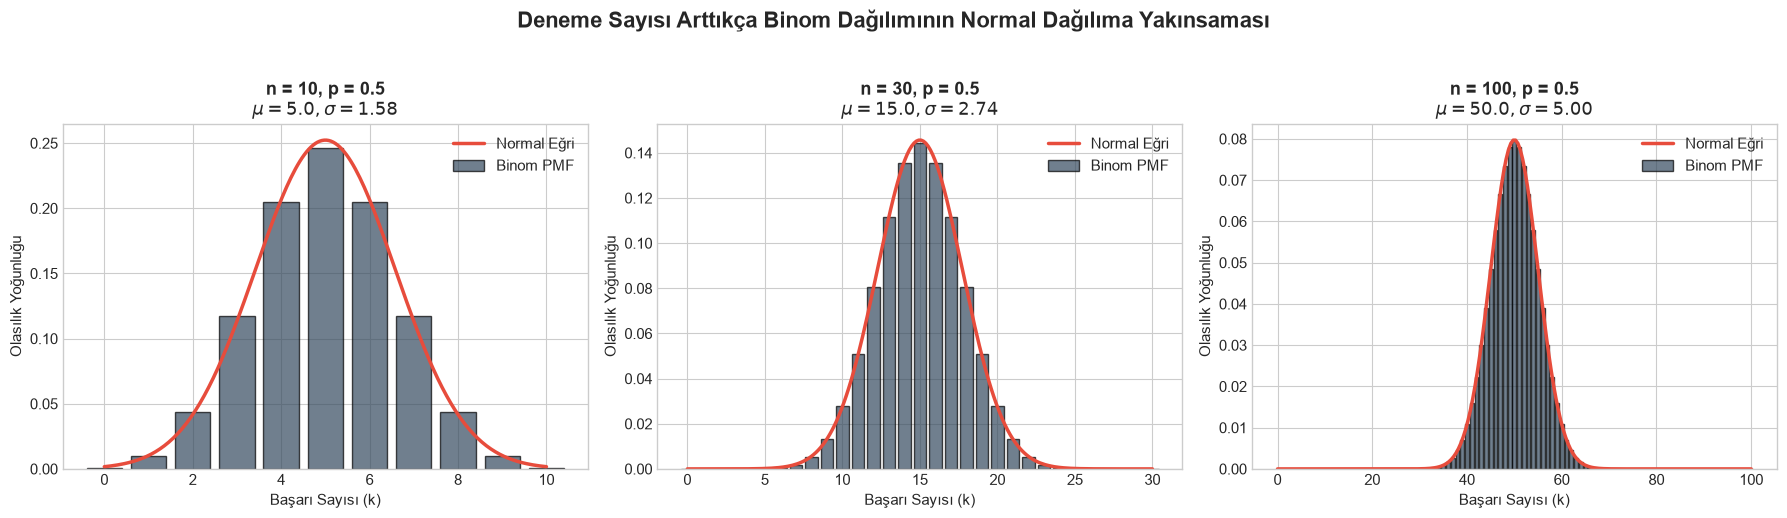

In [8]:
p = 0.5
n_list = [10, 30, 100]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, n_val in enumerate(n_list):
    k_vals = np.arange(0, n_val + 1)
    pmf_vals = binom.pmf(k_vals, n=n_val, p=p)
    
    axes[idx].bar(k_vals, pmf_vals, color='#34495e', alpha=0.7, edgecolor='black', width=0.8, label='Binom PMF')
    
    # Normal yaklaşım eğrisi çizimi (mu = np, sigma = sqrt(np(1-p)))
    mu = n_val * p
    sigma = np.sqrt(n_val * p * (1 - p))
    x_norm = np.linspace(0, n_val, 200)
    norm_pdf = stats.norm.pdf(x_norm, mu, sigma)
    axes[idx].plot(x_norm, norm_pdf, color='#e74c3c', linewidth=2.5, label='Normal Eğri')
    
    axes[idx].set_title(f'n = {n_val}, p = {p}\n$\mu={mu:.1f}, \sigma={sigma:.2f}$', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Başarı Sayısı (k)', fontsize=11)
    axes[idx].set_ylabel('Olasılık Yoğunluğu', fontsize=11)
    axes[idx].legend(loc='upper right')

plt.suptitle('Deneme Sayısı Arttıkça Binom Dağılımının Normal Dağılıma Yakınsaması', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 🎨 Grafik 3: PMF ve Kümülatif Dağılım Fonksiyonu (CDF) Karşılaştırması

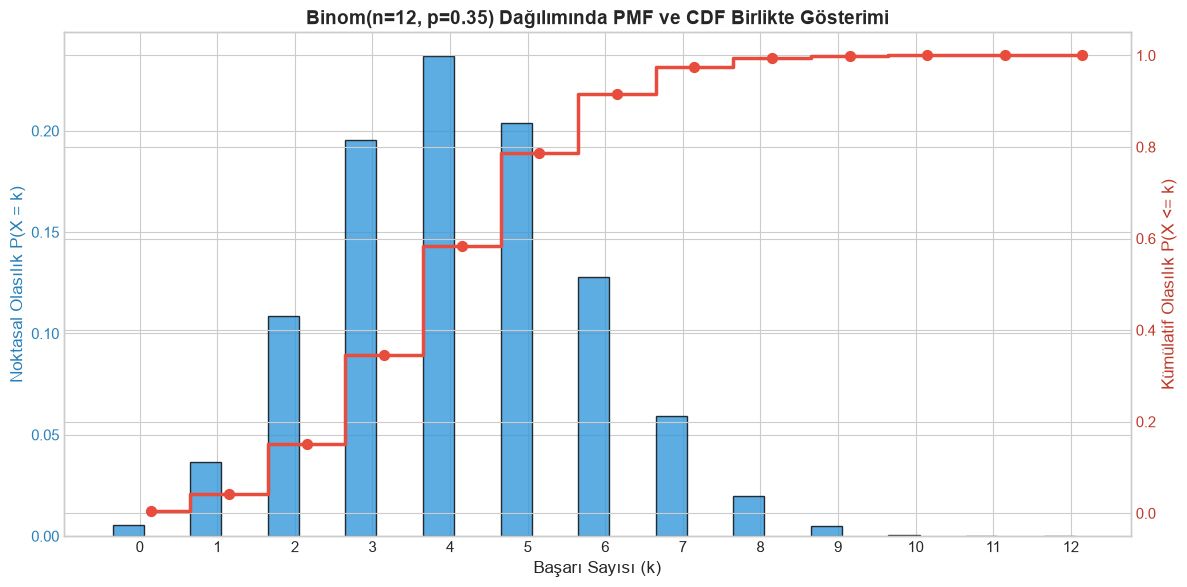

In [9]:
n = 12
p = 0.35
k_vals = np.arange(0, n + 1)

pmf_vals = binom.pmf(k_vals, n=n, p=p)
cdf_vals = binom.cdf(k_vals, n=n, p=p)

fig, ax1 = plt.subplots(figsize=(12, 6))

# PMF Çubuk Grafiği (Sol Eksen)
ax1.bar(k_vals - 0.15, pmf_vals, width=0.4, color='#3498db', alpha=0.8, label='PMF: P(X = k)', edgecolor='black')
ax1.set_xlabel('Başarı Sayısı (k)', fontsize=12)
ax1.set_ylabel('Noktasal Olasılık P(X = k)', color='#2980b9', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_xticks(k_vals)

# CDF Basamak Grafiği (Sağ Eksen)
ax2 = ax1.twinx()
ax2.step(k_vals + 0.15, cdf_vals, where='mid', color='#e74c3c', linewidth=2.5, label='CDF: P(X <= k)')
ax2.scatter(k_vals + 0.15, cdf_vals, color='#e74c3c', s=50, zorder=5)
ax2.set_ylabel('Kümülatif Olasılık P(X <= k)', color='#c0392b', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax2.set_ylim(-0.05, 1.05)

plt.title(f'Binom(n={n}, p={p}) Dağılımında PMF ve CDF Birlikte Gösterimi', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

### 🎨 Grafik 4: Monte Carlo Simülasyonu ile Büyük Örneklem Testi (10.000 Deney)

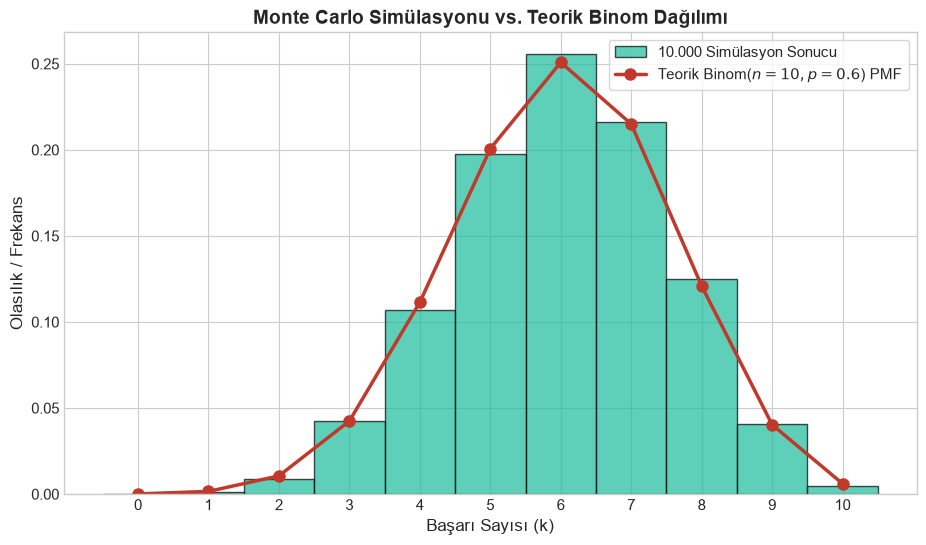

In [10]:
n_trials = 10
p_success = 0.6
num_simulations = 10000

# 10.000 adet Binom deneyi simülasyonu
simulated_data = np.random.binomial(n=n_trials, p=p_success, size=num_simulations)

# Teorik PMF
x_axis = np.arange(0, n_trials + 1)
theoretical_pmf = binom.pmf(x_axis, n=n_trials, p=p_success)

plt.figure(figsize=(11, 6))

# Simülasyon sonuçlarının normalize edilmiş histogramı
plt.hist(simulated_data, bins=np.arange(-0.5, n_trials + 1.5, 1), density=True, 
         color='#1abc9c', edgecolor='black', alpha=0.7, label='10.000 Simülasyon Sonucu')

# Teorik PMF çizgisi
plt.plot(x_axis, theoretical_pmf, color='#c0392b', marker='o', linewidth=2.5, 
         markersize=8, label=r'Teorik Binom($n=10, p=0.6$) PMF')

plt.title('Monte Carlo Simülasyonu vs. Teorik Binom Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Başarı Sayısı (k)', fontsize=12)
plt.ylabel('Olasılık / Frekans', fontsize=12)
plt.xticks(x_axis)
plt.legend(frameon=True, fontsize=11)
plt.show()

---
## 🔗 8. Binom Dağılımı ile Diğer Dağılımların İlişkisi

1. **Bernoulli Dağılımı ile İlişki:** $n=1$ olduğunda $\text{Binomial}(1, p) \equiv \text{Bernoulli}(p)$.
2. **Poisson Dağılımına Yakınsama (Poisson Limit Teoremi):** $n \to \infty$ ve $p \to 0$ iken $n \cdot p = \lambda$ sabit tutulursa, Binom dağılımı **Poisson Dağılımı**'na yakınsar:
   $$\lim_{n \to \infty} \binom{n}{k} p^k (1-p)^{n-k} = \frac{\lambda^k e^{-\lambda}}{k!}$$
3. **Normal Dağılıma Yakınsama (De Moivre - Laplace Teoremi):** $n$ büyük olduğunda ($n p \ge 5$ ve $n(1-p) \ge 5$), Binom dağılımı $\mathcal{N}(\mu = np, \sigma^2 = np(1-p))$ Normal dağılımına yaklaşır.

---
## 📝 9. Özet ve Hızlı Başvuru Kartı

| Özellik | Formül / Açıklama |
| :--- | :--- |
| **Dağılım Türü** | Ayrık (Discrete) |
| **Parametreler** | $n \in \mathbb{N}^+$ (Deneme Sayısı), $p \in [0, 1]$ (Başarı Olasılığı) |
| **Tanım Kümesi** | $k \in \{0, 1, 2, \dots, n\}$ |
| **PMF** | $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$ |
| **Beklenen Değer** | $E[X] = n \cdot p$ |
| **Varyans** | $\text{Var}(X) = n \cdot p \cdot (1 - p)$ |
| **Python SciPy** | `scipy.stats.binom(n, p)` |
| **Python NumPy** | `np.random.binomial(n, p, size)` |

---